# Team Members & Contributions:

Iain: Obtained AQI data and completed the EDA section for it.

Diego: Obtained demographic data and completed the EDA section for it.

Christina: Tidied AQI data, completed ANOVA testing, and completed linear regression testing.

John: Did not contribute.

# Research Questions

1. How do air quality patterns, as measured through the mean Air Quality Index scores, differ between coastal and inland regions of San Diego county, with coastal regions being measured as the zip codes that contain the coast and inland regions being measured as zip codes that do not contain the coast? 
2. Is there a correlation between the air quality patterns, as measured through the mean Air Quality Index scores, and disparities in health outcomes, as measured by rates of asthma in each zip code, when controlling for other variables (income, median age, etc.)?

# Data Collection and Exploration

In [43]:
# Import necessary packages
#%pip install pgeocode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import scipy.stats as stats
import pingouin as pg
import pgeocode
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

First, in order to answer our research questions, we need data on the Air Quality Index scores for each region of San Diego. We found that IQAir, an air quality data resource, has an API on their website for the air quality index scores for each region in San Diego. However, requesting an ID for the API is taking some time, so in the meantime, we have manually obtained some data from the website.

## Wrangling AQI Data

In [44]:
file_path = 'aqi_data.csv'
aqi_df = pd.read_csv(file_path)
aqi_df.head()

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2021,AQS,60730001,1,0.040,ppm,37,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
1,01/02/2021,AQS,60730001,1,0.038,ppm,35,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
2,01/03/2021,AQS,60730001,1,0.041,ppm,38,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
3,01/04/2021,AQS,60730001,1,0.039,ppm,36,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
4,01/05/2021,AQS,60730001,1,0.034,ppm,31,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088


In [45]:
aqi_df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

First, let's simplify the dataset by only selecting the columns relevant for our data analysis, and also change date into a pd DateTime object.

In [46]:
aqi_df = aqi_df[['Date', 'Site ID', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Site Latitude', 'Site Longitude']]

aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])

Next, let us add a column to label the sites as being coastal or inland based on their longitude. Sites with a longitude less  than -117.3 will be considered coastal.

In [47]:
coastal_stations = [
    "Chula Vista",
    "Camp Pendleton",
    "San Diego - Sherman Elementary School"
]


urban_stations = [
    "San Diego - Kearny Villa Rd.",
    "El Cajon - Lexington Elementary School",
    "Donovan"
]

inland_stations = [
    "Alpine",
    "Pala Airpad",
    "La Posta Band of Indians"
]

aqi_df['Coastal'] = np.where(aqi_df['Local Site Name'].isin(coastal_stations), 1, 0)
aqi_df['Inland'] = np.where(aqi_df['Local Site Name'].isin(inland_stations), 1, 0)
aqi_df.head()

,Date,Site ID,Daily AQI Value,Local Site Name,Daily Obs Count,Site Latitude,Site Longitude,Coastal,Inland
0,2021-01-01,60730001,37,Chula Vista,17,32.631242,-117.059088,1,0
1,2021-01-02,60730001,35,Chula Vista,17,32.631242,-117.059088,1,0
2,2021-01-03,60730001,38,Chula Vista,17,32.631242,-117.059088,1,0
3,2021-01-04,60730001,36,Chula Vista,17,32.631242,-117.059088,1,0
4,2021-01-05,60730001,31,Chula Vista,17,32.631242,-117.059088,1,0


## EDA for AQI Data

In [48]:
df = aqi_df.set_index('Local Site Name')

This graph shows us that there are overall trends that influence the air quality patterns for every region, though there is some variation between the regions. For example, every region has comparatively better air quality than normal on November 5th.

***Quick Summary of Cities and Their Avg, Best, and Worst AQI Score***

In [49]:
aqi_summary = pd.DataFrame({
    "Avg AQI": df.mean(axis=1),
    "Best (Lowest) AQI": df.min(axis=1),
    "Worst (Highest) AQI": df.max(axis=1)
}).sort_values("Avg AQI")

aqi_summary

TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

In [ ]:
aqi_summary.to_csv('aqi_summary.csv')

This is one way of showing us the variability in each region's air quality. Just like in the above graphs, La Jolla Shores and Petco Park have the worst recorded air quality scores, with the other regions remaining far below.

## Obtaining and Cleaning Demographic Data

In [ ]:
## Loading packages
#pip install census requests us
import os
import pandas as pd
import numpy as np
from census import Census
from us import states
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Census API key
plt.rcParams["figure.figsize"] = (8, 4)

# --- keys & constants ---
CENSUS_API_KEY = "ce8b9610a02a2db4fd9e5ccb0412895621293667"
c = Census(CENSUS_API_KEY)

In [ ]:
STATE_FIPS = states.CA.fips          # '06'
SAN_DIEGO_COUNTY_FIPS = "073"        # San Diego County
START_YEAR = 2018
END_YEAR = 2023

# folder for any local CSVs you download
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
ACS_VARS = {
    "B01003_001E": "pop_total",
    "B19013_001E": "med_income",
    "B01002_001E": "med_age",
    "B02001_002E": "white_alone",
    "B02001_003E": "black_alone",
    "B02001_005E": "asian_alone",
    "B03002_012E": "hispanic_any",
    "B17001_002E": "pop_below_poverty",
}

acs_cols = tuple(ACS_VARS.keys()) + ("NAME",)

tracts_raw = c.acs5.state_county_tract(
    acs_cols,
    STATE_FIPS,
    SAN_DIEGO_COUNTY_FIPS,
    Census.ALL
)

acs = pd.DataFrame(tracts_raw)
acs.rename(columns=ACS_VARS, inplace=True)

# construct full GEOID
acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]

# some handy fractions
acs["p_white"] = acs["white_alone"] / acs["pop_total"]
acs["p_black"] = acs["black_alone"] / acs["pop_total"]
acs["p_asian"] = acs["asian_alone"] / acs["pop_total"]
acs["p_hispanic"] = acs["hispanic_any"] / acs["pop_total"]
acs["p_poverty"] = acs["pop_below_poverty"] / acs["pop_total"]

In [ ]:
# Classify tracts as coastal or inland based on distance from tract centroids to the coast

def get_tract_centroids(state_fips="06", county_fips="073"):
    layer = 10  # Census Tracts layer
    url = (
        f"https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/Tracts_Blocks/MapServer/{layer}/query"
        f"?where=STATE+%3D+'{state_fips}'+AND+COUNTY+%3D+'{county_fips}'"
        f"&outFields=STATE,COUNTY,TRACT"
        f"&returnGeometry=true&geometryPrecision=6&outSR=4326"
        f"&f=json"
    )

    resp = requests.get(url).json()

    if "features" not in resp:
        print("API returned an error:", resp)
        raise ValueError("TIGERweb query failed")

    rows = []

    for feat in resp["features"]:
        attrs = feat["attributes"]
        geom = feat["geometry"]["rings"][0]

        xs = [p[0] for p in geom]
        ys = [p[1] for p in geom]
        lon = sum(xs) / len(xs)
        lat = sum(ys) / len(ys)

        rows.append({
            "STATE": attrs["STATE"],
            "COUNTY": attrs["COUNTY"],
            "TRACT": attrs["TRACT"],
            "centroid_lon": lon,
            "centroid_lat": lat
        })

    return pd.DataFrame(rows)

centroids = get_tract_centroids()
centroids["GEOID"] = centroids["STATE"] + centroids["COUNTY"] + centroids["TRACT"]

In [ ]:
acs = acs.merge(centroids, on="GEOID", how="left")

acs["region"] = acs["centroid_lon"].apply(
    lambda x: "coastal" if x > -117.25 else "inland"
)

acs["region"].value_counts()

In [ ]:
## Checking for bad data
len(acs[(acs['med_income'] < 0) | (acs['med_age'] < 0)])

While there are very few missing values, some tracts have too low of a population and/or its estimates for median income and median age were too unreliable, that's why a lot of these plots look so skewed, therefore the 8 rows above will be dropped.

In [ ]:
bad_rows = acs[(acs['med_income'] < 0) | (acs['med_age'] < 0)]
acs = acs[~((acs['med_income'] < 0) | (acs['med_age'] < 0))].copy()

## EDA for Demographic Data

In [ ]:
num_cols = ["pop_total", "med_income", "med_age", "p_poverty"]

acs[num_cols].hist(bins=30, figsize=(12, 8), edgecolor="black")
plt.suptitle("Distribution of Key ACS Variables", fontsize=16)
plt.show()

In [ ]:
## Select 10 most populated tracts, making sure there are at least 3 coastal or 3 inland
most_pop_10 = acs.sort_values(by='pop_total')[:10]
most_pop_10['region'].value_counts()

## Cleaning Asthma Data

In [50]:
# Load in data
asthma = pd.read_csv('asthmaedvisitrates-by-zipcode-2013to2022-allages-ca-cdph_with-county.csv')

In [51]:
## Only select San Diego county and drop NA
asthma_sd = asthma[asthma['county']=='San Diego'].dropna()

In [ ]:
## Making sure the type and name of the zip code column is the same as in the AQI dataset
asthma_by_zipcode = pd.DataFrame(asthma_sd.groupby('Zip_Code')['Number_of_Asthma_ED_Visits'].mean()).reset_index()
asthma_by_zipcode['Zip_Code'] = asthma_by_zipcode['Zip_Code'].astype(int)
asthma_by_zipcode.columns = ['Zip Code', 'Number_of_Asthma_ED_Visits']
asthma_by_zipcode

In [ ]:
## check relationship between respiratory illness and how populated the zip codes are

## use proportion of respiratory illness by population

## EDA for Asthma Data

In [ ]:
asthma_sd[['Number_of_Asthma_ED_Visits', 'Age_Adjusted_Rate_of_Asthma_ED_V']].describe()

In [55]:
asthma_sd.head()

,Year,Zip_Code,county,Age_Group,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
280,2013,91901,San Diego,All Ages,52,34.9
281,2013,91902,San Diego,All Ages,55,33.4
282,2013,91906,San Diego,All Ages,25,74.7
283,2013,91910,San Diego,All Ages,375,50.6
284,2013,91911,San Diego,All Ages,528,61.9


Text(0.5, 1.0, 'Total Number of Asthma ED Visits for Each Zip Code by Year')

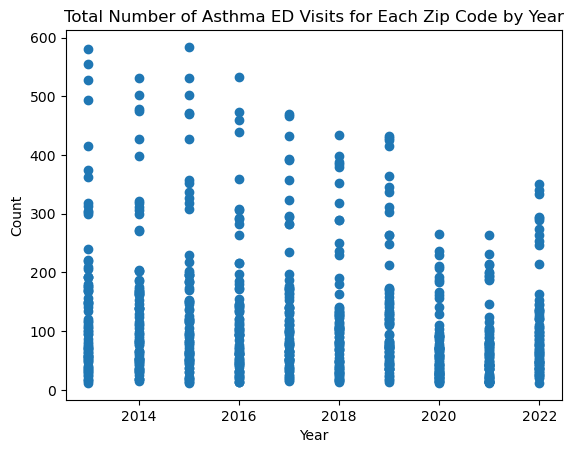

In [58]:
plt.scatter(asthma_sd['Year'], asthma_sd['Number_of_Asthma_ED_Visits'])
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total Number of Asthma ED Visits for Each Zip Code by Year')

# Analysis

## ANOVA Testing for AQI Between the 10 Most Populated Coastal and Inland Zip Codes

### Checking Conditions

In order to do ANOVA testing, the data must fulfill 3 conditions.

First, each observation must be independent. This can be reasonably assumed to be fulfilled even though there are broader trends within the AQI score for each date, because our ANOVA testing does not discern based on date.

Next, the dependent variable must be normally distributed. We can check that with a histogram below. While the data has a slight right skew, it is not too far from having a Gaussian distribution, and thus this condition can be considered to be met.

Third, the variability between each group must be similar. This can be checked with a box plot below. The variability for Petco Park and La Jolla appear to be higher than the other regions. In order to mitigate this, we should drop outliers.

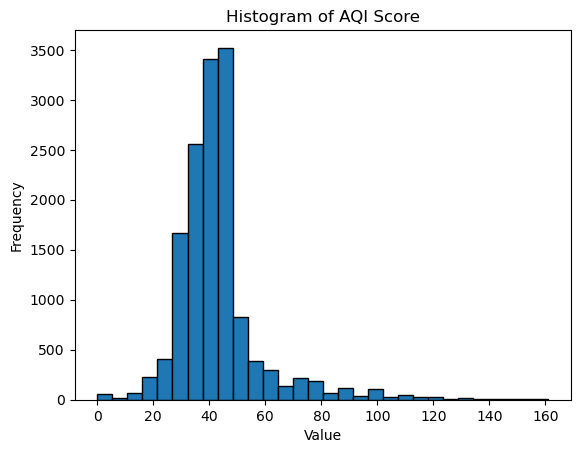

In [59]:
plt.hist(aqi_df['Daily AQI Value'], bins=30, edgecolor='black') # bins argument controls the number of bins
plt.title('Histogram of AQI Score')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

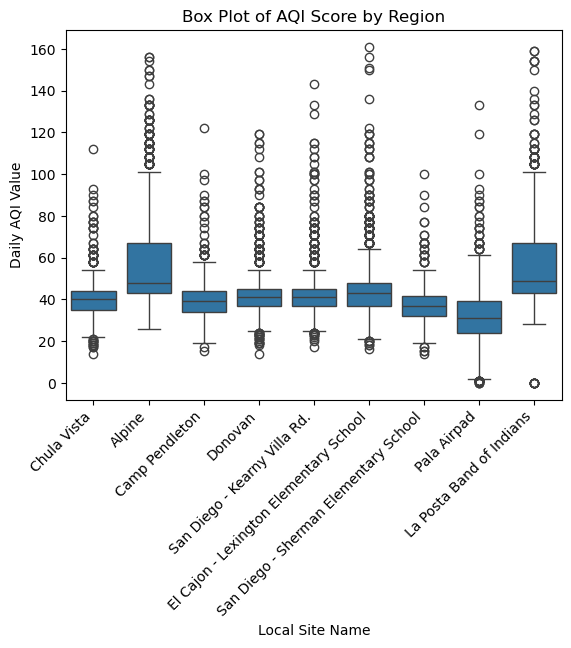

In [60]:
sns.boxplot(x='Local Site Name', y='Daily AQI Value', data=aqi_df.reset_index())
plt.title('Box Plot of AQI Score by Region')
plt.xticks(rotation=45, ha='right')
plt.show()

In [61]:
regions = aqi_df['Local Site Name'].unique()

array_dict = {}
for region in regions:
    array_dict[region] = np.array(aqi_df[aqi_df['Local Site Name']==region]['Daily AQI Value'])

array_dict.keys()

chula = np.array(aqi_df[aqi_df['Local Site Name']=='Chula Vista']['Daily AQI Value'])
alpine = np.array(aqi_df[aqi_df['Local Site Name']=='Alpine']['Daily AQI Value'])
pendleton = np.array(aqi_df[aqi_df['Local Site Name']=='Camp Pendleton']['Daily AQI Value'])
donovan = np.array(aqi_df[aqi_df['Local Site Name']=='Donovan']['Daily AQI Value'])
kearny = np.array(aqi_df[aqi_df['Local Site Name']=='San Diego - Kearny Villa Rd.']['Daily AQI Value'])
cajon = np.array(aqi_df[aqi_df['Local Site Name']=='El Cajon - Lexington Elementary School']['Daily AQI Value'])
sherman = np.array(aqi_df[aqi_df['Local Site Name']=='San Diego - Sherman Elementary School']['Daily AQI Value'])
pala = np.array(aqi_df[aqi_df['Local Site Name']=='Pala Airpad']['Daily AQI Value'])
la_posta = np.array(aqi_df[aqi_df['Local Site Name']=='La Posta Band of Indians']['Daily AQI Value'])

In [62]:
f_statistic, p_value = stats.f_oneway(chula, alpine, pendleton, donovan, kearny, cajon, sherman, pala, la_posta)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

F-statistic: 580.6329815470166
P-value: 0.0


In [ ]:
pivot = df.pivot_table(
    index='Date',
    columns='Local Site Name',
    values='Daily AQI Value'
)

coastal = pivot[coastal_stations].mean(axis=1)
inland  = pivot[inland_stations].mean(axis=1)

coastal_smooth = coastal.rolling(window=7, center=True).mean()
inland_smooth = inland.rolling(window=7, center=True).mean()

plt.figure(figsize=(12,5))

plt.plot(coastal, label="Coastal AQI (mean of coastal stations)", alpha=0.85)
plt.plot(inland, label="Inland AQI (mean of inland stations)", alpha=0.75)

plt.title("Daily AQI Comparison: Coastal vs Inland Regions of San Diego (2021–2025)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily AQI Value (8-hour Ozone)", fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## T-Test and Bootstrapping Analysis

Because the main question that we want to answer is if the distributions of AQI for coastal and inland regions, which are essentially two large samples, are different, we will do a 2 sample T-test, using Welch's correction, as the variances are different. 

In [63]:
## Obtaining coastal and inland AQI distribution arrays
coastal = aqi_df[aqi_df['Coastal']==1]['Daily AQI Value']
inland = aqi_df[aqi_df['Inland']==1]['Daily AQI Value']

## 2 Sample T-Test
result = pg.ttest(coastal, inland, correction=True)
print(result)

               T          dof alternative          p-val          CI95%  \
T-test -24.86141  5287.111907   two-sided  3.945696e-129  [-9.72, -8.3]   

         cohen-d        BF10  power  
T-test  0.543345  1.493e+128    1.0  


In [ ]:
## sampling from inland n times and coastal n times, both with replacement. 
## Then you plot a histogram for both and you should get a bell curve for both. 
## Then you layer one over the other and one should be shifted compared to the other
iters = 1000
coastal_boot = []
for _ in range(iters):
    bootstrap_sample = np.random.choice(coastal, size=len(coastal), replace=True)
    coastal_boot.append(bootstrap_sample.mean())

inland_boot = []
for _ in range(iters):
    bootstrap_sample = np.random.choice(inland, size=len(inland), replace=True)
    inland_boot.append(bootstrap_sample.mean())

In [ ]:
plt.hist(coastal_boot, bins=30, alpha=0.5, label='Coastal', color='blue')
plt.hist(inland_boot, bins=30, alpha=0.5, label='Inland', color='red')
plt.title('Distribution of Mean Daily AQI for Coastal and Inland Regions')
plt.legend()

## Linear Regression for AQI and Rate of Asthma

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
aqi_asthma = pd.merge(aqi_zip_df, asthma_by_zipcode, how='left', on='Zip Code').dropna().groupby('Zip Code')[['AQI Score', 'Number_of_Asthma_ED_Visits']].mean()

In [ ]:
x = np.array(aqi_asthma['AQI Score']).reshape(-1,1)
y = np.array(aqi_asthma['Number_of_Asthma_ED_Visits']).reshape(-1,1)

model = LinearRegression()
model.fit(x, y)
print(f"Slope (B1): {model.coef_[0]}")
print(f"Intercept (B0): {model.intercept_}")
r_squared = model.score(x, y)
print(f"R-squared: {r_squared}")

In [ ]:
sns.regplot(x='AQI Score', y='Number_of_Asthma_ED_Visits', data=aqi_asthma)
plt.title('Linear Regression of Mean AQI Score to Number of Asthma Visits for Each Zip Code')
plt.show()

# Outline of Work for Completing the Project

Iain: Will obtain full AQI data and create clean visualizations for the first research question 

Christina: Will conduct T-test and ANOVA testing for the first research question. Will also write about the background and importance of the research questions.

Diego: Will conduct regression analysis between the AQI scores and respiratory illness rates for the second research question

John: Will create clean visualizations for the second research question and create the presentation slides.

All members will work on writing the conclusions.